In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [73]:
file_path = 'city_day.csv'
df = pd.read_csv(file_path)

#Display first rows
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [74]:
#Dataset information

print("Dataset Shape:")
print(df.shape)

print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

Dataset Shape:
(29531, 16)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 3.6 MB
None

Summary Statistics:
              PM2.5          PM10            NO

In [75]:
#Missing values

missing_values = df.isnull().sum().sort_values(ascending=False)

missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

missing_df

,Missing Values,Percentage
Xylene,18109,61.322001
PM10,11140,37.723071
NH3,10328,34.973418
Toluene,8041,27.229014
Benzene,5623,19.041008
AQI,4681,15.851139
AQI_Bucket,4681,15.851139
PM2.5,4598,15.570079
NOx,4185,14.171549
O3,4022,13.619586


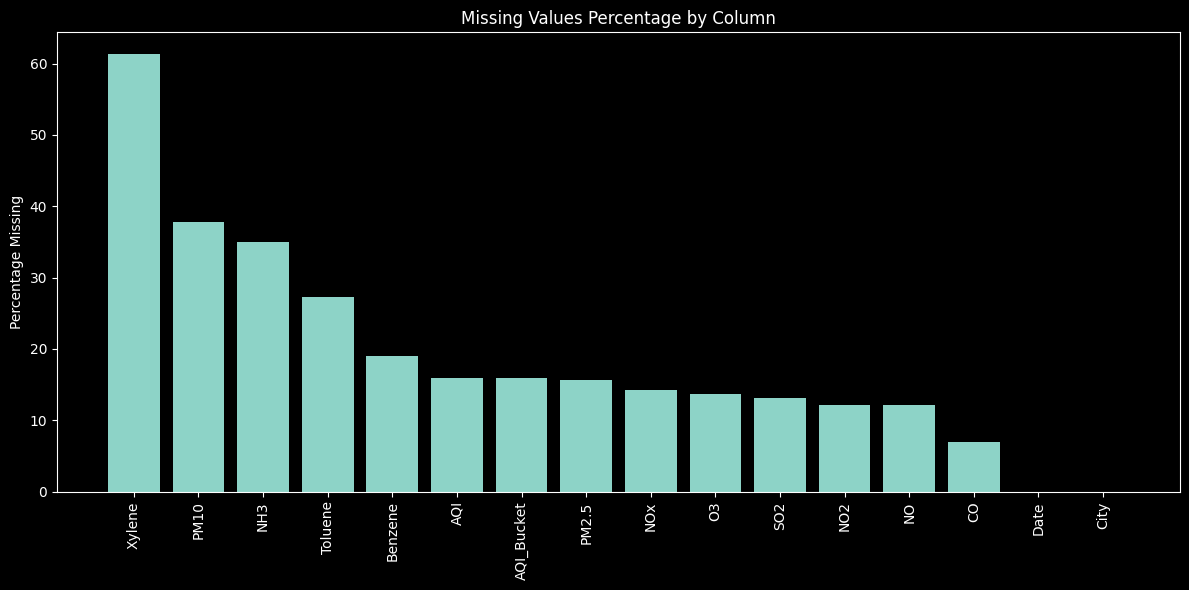

In [76]:
#Plotting missing values percentages

plt.figure(figsize=(12,6))

plt.bar(missing_df.index, missing_df['Percentage'])

plt.xticks(rotation=90)

plt.ylabel('Percentage Missing')

plt.title('Missing Values Percentage by Column')

plt.tight_layout()

plt.show()

In [77]:
#Convert Date column to datetime

df['Date'] = pd.to_datetime(df['Date'])

pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']

#Fill missing values using median

for col in pollutants:
    df[col] = df[col].fillna(df[col].median())

#Removing duplicate rows

df = df.drop_duplicates()

print("Cleaned Dataset Shape:")
print(df.shape)

Cleaned Dataset Shape:
(29531, 16)


In [78]:
#Create Pollution Index

df['Pollution_Index'] = (
    df['PM2.5'] + df['PM10'] + df['NO2']
) / 3

#PM Ratio

df['PM_Ratio'] = df['PM2.5'] / (df['PM10'] + 1)

#Extracting year and month

df['Year'] = df['Date'].dt.year

df['Month'] = df['Date'].dt.month

#Pollution category function

def pollution_category(pm):

    if pm <= 50:
        return 'Low'

    elif pm <= 100:
        return 'Moderate'

    elif pm <= 200:
        return 'High'

    else:
        return 'Severe'

df['Pollution_Category'] = df['PM2.5'].apply(pollution_category)

df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Pollution_Index,PM_Ratio,Year,Month,Pollution_Category
0,Ahmedabad,2015-01-01,48.57,95.68,0.92,18.22,17.15,NaN,0.92,27.64,...,0.00,0.02,0.00,NaN,NaN,54.156667,0.502379,2015,1,Low
1,Ahmedabad,2015-01-02,48.57,95.68,0.97,15.69,16.46,NaN,0.97,24.55,...,3.68,5.50,3.77,NaN,NaN,53.313333,0.502379,2015,1,Low
2,Ahmedabad,2015-01-03,48.57,95.68,17.40,19.30,29.70,NaN,17.40,29.07,...,6.80,16.40,2.25,NaN,NaN,54.516667,0.502379,2015,1,Low
3,Ahmedabad,2015-01-04,48.57,95.68,1.70,18.48,17.97,NaN,1.70,18.59,...,4.43,10.14,1.00,NaN,NaN,54.243333,0.502379,2015,1,Low
4,Ahmedabad,2015-01-05,48.57,95.68,22.10,21.42,37.76,NaN,22.10,39.33,...,7.01,18.89,2.78,NaN,NaN,55.223333,0.502379,2015,1,Low


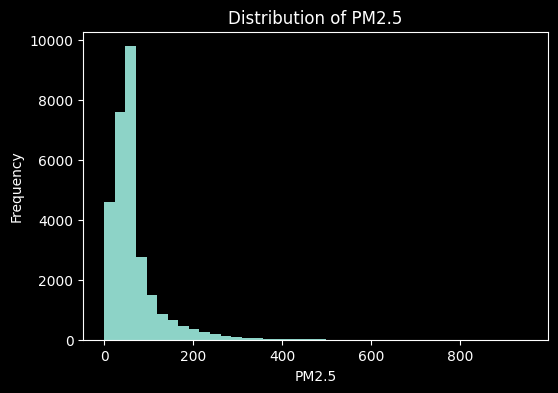

In [79]:
#Plot pollutant distributions

features = ['SO2', 'PM10', 'NO2', 'PM2.5']

for feature in features:

    plt.figure(figsize=(6,4))

    plt.hist(df[feature], bins=40)

    plt.xlabel(feature)

    plt.ylabel('Frequency')

    plt.title(f'Distribution of {feature}')

    plt.show()

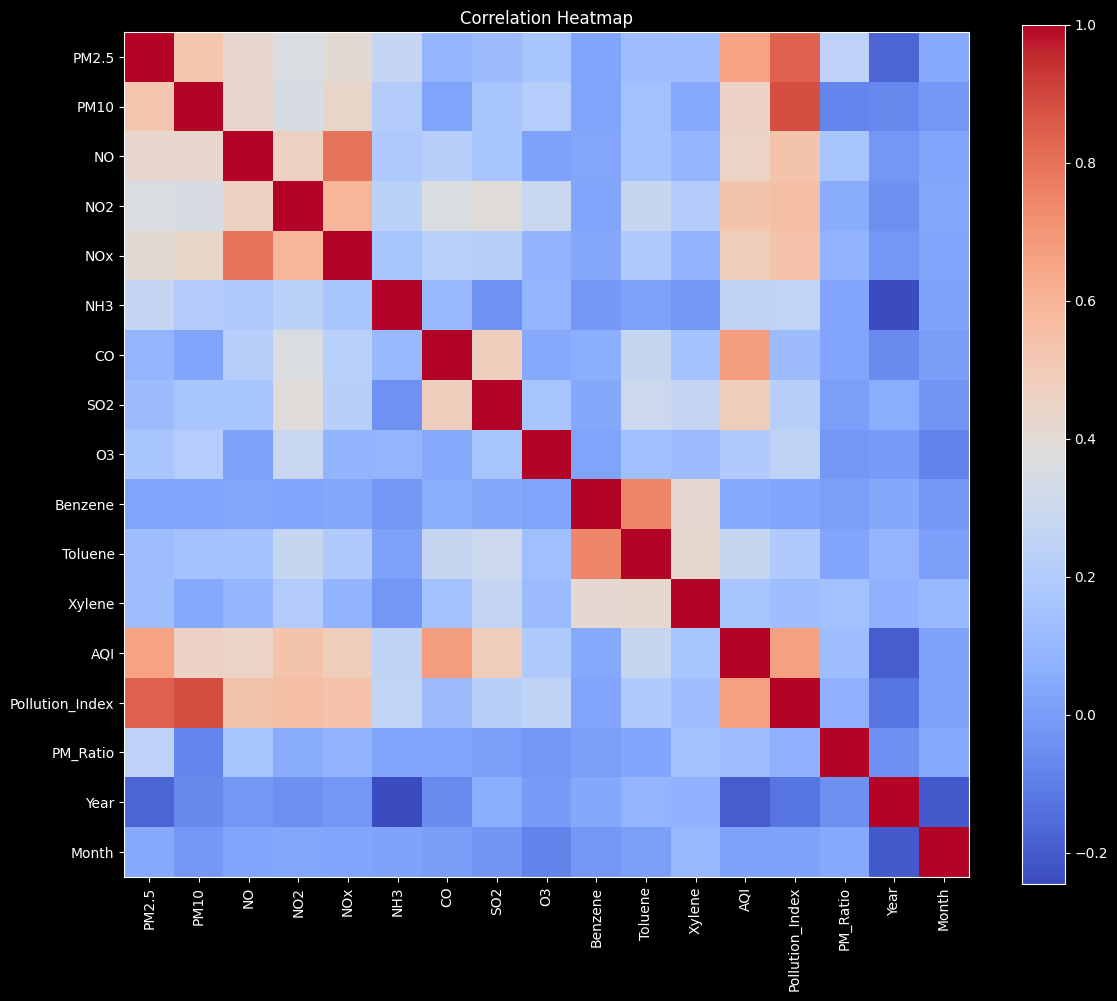

In [80]:
#Correlation matrix

numeric_df = df.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12,10))

plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')

plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title('Correlation Heatmap')

plt.tight_layout()

plt.show()

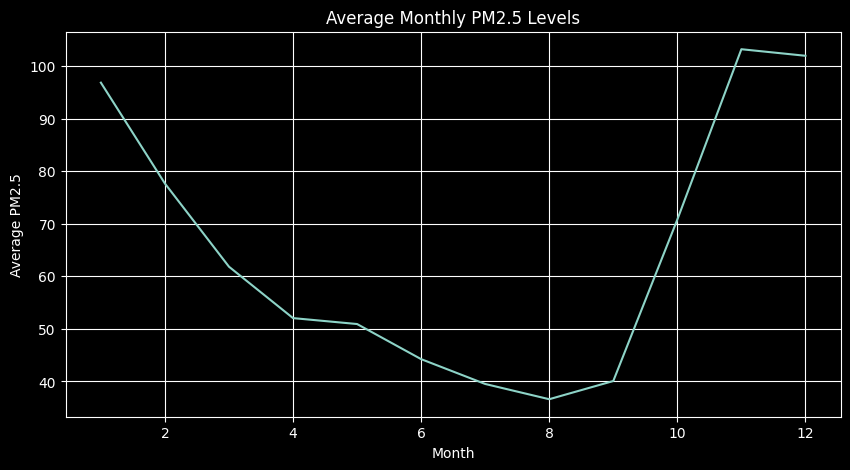

In [81]:
#Monthly average PM2.5

monthly_pollution = df.groupby('Month')['PM2.5'].mean()

plt.figure(figsize=(10,5))

plt.plot(
    monthly_pollution.index,
    monthly_pollution.values
)

plt.xlabel('Month')

plt.ylabel('Average PM2.5')

plt.title('Average Monthly PM2.5 Levels')

plt.grid(True)

plt.show()

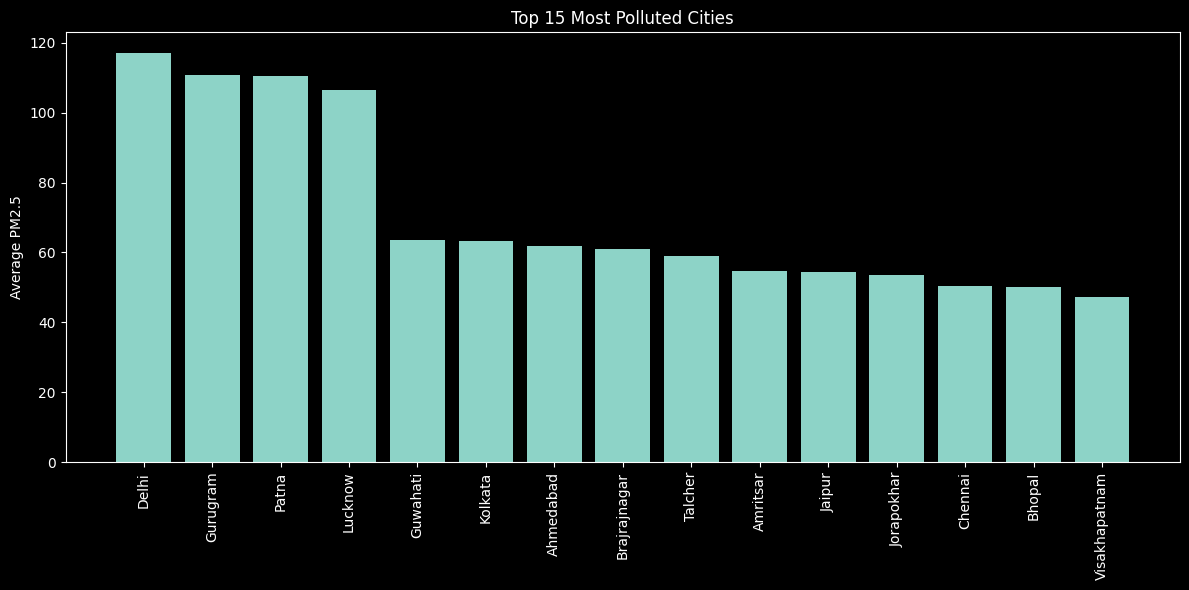

In [82]:
#Average PM2.5 by city

city_pollution = (
    df.groupby('City')['PM2.5']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

plt.bar(
    city_pollution.index[:15],
    city_pollution.values[:15]
)

plt.xticks(rotation=90)

plt.ylabel('Average PM2.5')

plt.title('Top 15 Most Polluted Cities')

plt.tight_layout()

plt.show()

In [83]:
#Features for PCA and clustering

pca_features = [
    'PM2.5',
    'PM10',
    'NO2',
    'SO2',
    'CO',
    'O3',
    'Pollution_Index',
    'PM_Ratio'
]

X = df[pca_features]

#Standardise data

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(29531, 8)


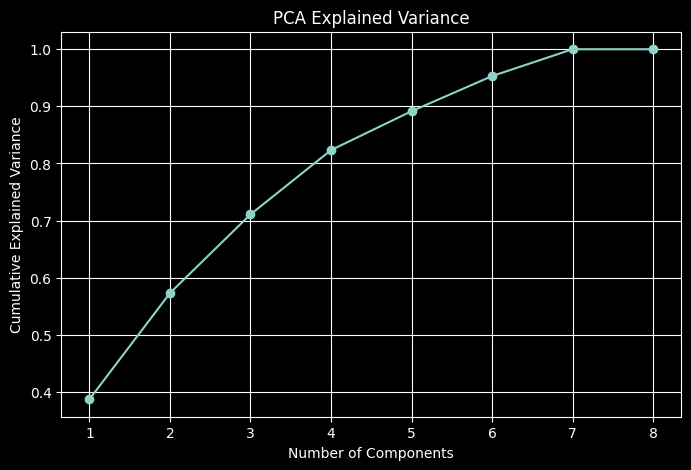

In [84]:
#PCA model

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(explained_variance)+1),
    explained_variance.cumsum(),
    marker='o'
)

plt.xlabel('Number of Components')

plt.ylabel('Cumulative Explained Variance')

plt.title('PCA Explained Variance')

plt.grid(True)

plt.show()

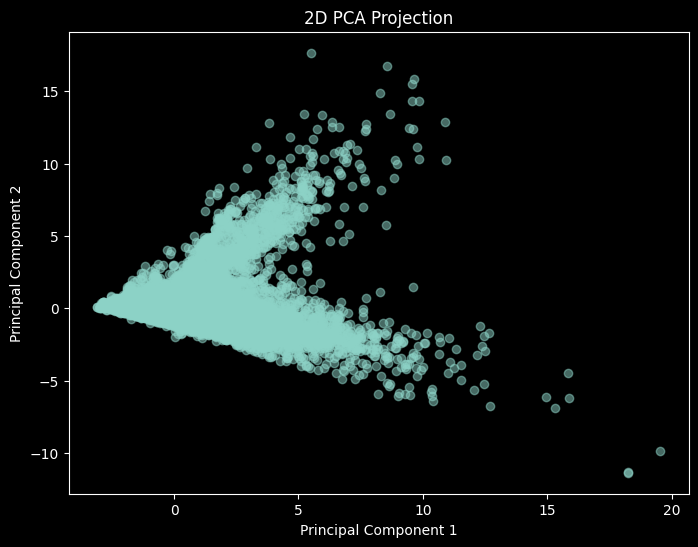

In [85]:
#PCA with 2 components

pca_2 = PCA(n_components=2)

X_pca_2 = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca_2[:,0],
    X_pca_2[:,1],
    alpha=0.5
)

plt.xlabel('Principal Component 1')

plt.ylabel('Principal Component 2')

plt.title('2D PCA Projection')

plt.show()

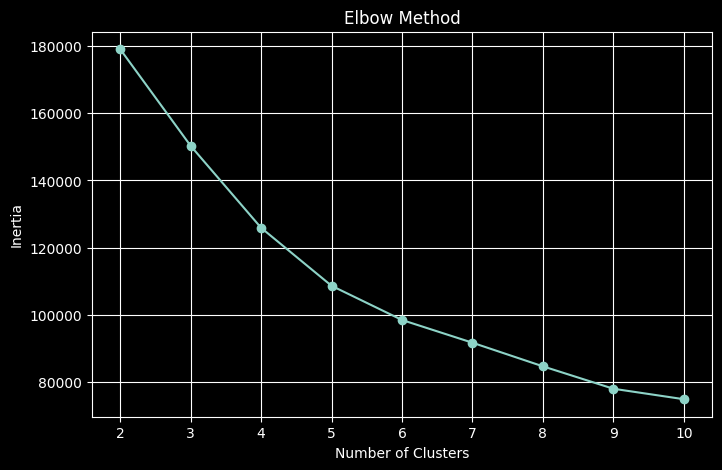

In [86]:
#Elbow method

inertia = []

K = range(2, 11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.xlabel('Number of Clusters')

plt.ylabel('Inertia')

plt.title('Elbow Method')

plt.grid(True)

plt.show()

In [87]:
#Apply K-Means

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

#Adding cluster labels

df['Cluster'] = clusters

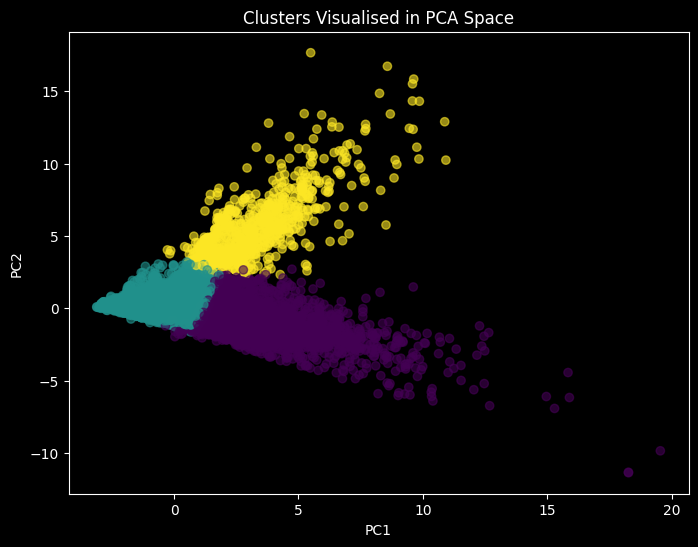

In [88]:
#Visualise clusters in PCA space

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca_2[:,0],
    X_pca_2[:,1],
    c=clusters,
    alpha=0.6
)

plt.xlabel('PC1')

plt.ylabel('PC2')

plt.title('Clusters Visualised in PCA Space')

plt.show()